#**Using CNN to classify different images**

Dataset :  ["Intel_Image_Classification" from Kaggle](https://www.kaggle.com/datasets/puneet6060/intel-image-classification?utm_)

This Data contains around 25k images of size 150x150 distributed under 6 categories.

- 'buildings' -> 0,

- 'forest' -> 1,

- 'glacier' -> 2,

- 'mountain' -> 3,

- 'sea' -> 4,

- 'street' -> 5

**The model will be trained on about 14k images**

**Goal : Building a Neural Network that may classify these images as accuartely as possible**

##importing necessary libraries

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from torch.optim import Adam
from torchvision import transforms, datasets
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt

In [34]:
device='cuda' if torch.cuda.is_available else 'cpu'
print(device)

cuda


Since I will be loading the dataset from my drive thus I must connect MyDrive to Notebook

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive')

['covid-19.csv',
 'Colab Notebooks',
 'Indian_rental_prices.csv',
 'House Price India.csv',
 'Housing_price_prediction_.pkl',
 'Housing_price_model.joblib',
 'Housing_price_prediction_.joblib',
 'diabetes_prediction_dataset.csv',
 'model_classification_.joblib',
 'riceClassification.csv',
 'dog-cat_img_data',
 'Intel_Image_Classification']

In [4]:
os.listdir('/content/drive/MyDrive/Intel_Image_Classification')

['seg_pred', 'seg_test', 'seg_train']

In [5]:
train_path=r'/content/drive/MyDrive/Intel_Image_Classification/seg_train/seg_train'
test_path=r'/content/drive/MyDrive/Intel_Image_Classification/seg_test/seg_test'
pred_path=r'/content/drive/MyDrive/Intel_Image_Classification/seg_pred/seg_pred'

In [6]:
print(
    f'Train : {len(os.listdir(train_path))}\n'
    f'Test  : {len(os.listdir(test_path))}\n'
    f'Pred  : {len(os.listdir(pred_path))}'
)

Train : 6
Test  : 6
Pred  : 7301


In [7]:
os.listdir('/content/drive/MyDrive/Intel_Image_Classification/seg_train/seg_train')

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [8]:
os.listdir(test_path)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

##Visulizing a images from train_data using PIL & matplotlib

File : 19456.jpg
Size : (150, 150)
Type : RGB



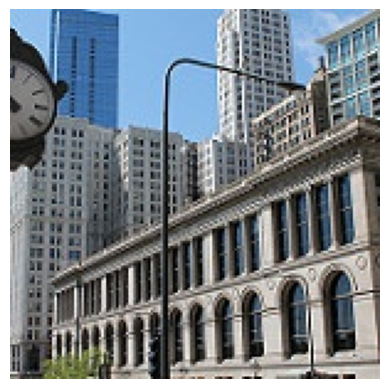

In [10]:
img_path=os.listdir('/content/drive/MyDrive/Intel_Image_Classification/seg_train/seg_train/buildings')[0]
img=os.path.join('/content/drive/MyDrive/Intel_Image_Classification/seg_train/seg_train/buildings', img_path)
image=Image.open(img)
print(
    f'File : {img_path}\n'
    f'Size : {image.size}\n'
    f'Type : {image.mode}\n'
)

plt.imshow(image)
plt.axis('off')
plt.show()

##Dataset class

In [40]:
class IntelDataset(Dataset):
  def __init__(self,img_folder,transform=None):
    super().__init__()
    self.img_folder=img_folder
    self.transform=transform
    self.classes=sorted(os.listdir(img_folder)) #gives an array ['buildings','mountains',...]
    self.class_to_idx={
        class_name:index
        for index,class_name in enumerate(self.classes) #enumerates() adds an index to every object in array , e.g: building:0; mountains:1...
    }
    # we have created a dictionary of {buildings:0, forest:1, glacier:2, ...}

    # Now we must create an array to store img_path for all the images
    self.samples=[]
    for class_name in self.classes: #goes throuch each folder first building then forest and so on .
      class_path=os.path.join(img_folder,class_name) #this builds path up till the class folder but not to each image itself
      labels=self.class_to_idx[class_name]

      for image_name in os.listdir(class_path):
        image_path=os.path.join(class_path,image_name) #final complete path to each image in a class/folder
        self.samples.append((image_path,labels)) #gives something like [('contents/drive/.../buildings/123.jpg',0),...('contents/drive/.../street/13899.jpg',5)]

  def __len__(self):
    return len(self.samples)

  def __getitem__(self,index):
    image_path, label=self.samples[index]
    image=Image.open(image_path).convert('RGB')
    if self.transform:
      image=self.transform(image) # image -> (150,150) & ToTensor()
    return image,label #returns (image_tensor, label(0/1/2...))

In [51]:
transform=transforms.Compose([
    transforms.Resize((150,150)),
    transforms.ToTensor()
])

train_dataset=IntelDataset(train_path,transform)
test_dataset=IntelDataset(test_path,transform)

In [52]:
print(len(train_dataset))
image,label = train_dataset[9]
print(image.shape)

14034
torch.Size([3, 150, 150])


##DatLoader

In [42]:
train_loader=DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
test_loader=DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=True
)

#class CNN

In [59]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d( # 2d convolution layer on img
        in_channels=3,
        out_channels=16,
        kernel_size=3,
        padding=1
    )

    self.pool=nn.MaxPool2d(kernel_size=2)

    self.conv2=nn.Conv2d(
        in_channels=16,
        out_channels=32,
        kernel_size=3,
        padding=1
    )

    self.linear1=nn.Linear(
       32*(37*37),
       128
    )

    self.linear2=nn.Linear(
        128,
        6
    )

  def forward(self,x):#input (32,3,150,150)

      x=self.conv1(x) # (32,16,150,150)
      x=torch.relu(x)
      x=self.pool(x) # (32,16,75,75)

      x=self.conv2(x) # (32,32,75,75)
      x=torch.relu(x)
      x=self.pool(x) # (32,32,37,37)

      x=torch.flatten(x,start_dim=1) # (32,32,37,37) --> (32,32*(37*37)) --> (32,43808)
      #flatten converts the tensor data (32,32,37,37) into a vector (32,43808) , start_dim leaves the batch size 32 i.e index=0 as it it and starts flattening from index=1

      x=self.linear1(x) # 43808 --> 128
      x=torch.relu(x)
      x=self.linear2(x) # 128 --> 6
      return x

In [60]:
model=CNN()